In [2]:

import pandas as pd
import numpy as np
import re
import emoji
import matplotlib.pyplot as plt
from collections import defaultdict
from gensim.models import Word2Vec
from konlpy.tag import Okt
from soynlp.normalizer import repeat_normalize
from kiwipiepy import Kiwi
from symspellpy_ko import KoSymSpell
from matplotlib import font_manager as fm, rc
from wordcloud import WordCloud
from tqdm import tqdm

In [3]:
df1 = pd.read_csv('최종 네이버블로그리뷰_내용만(살로몬)정제.csv')
texts1 = df1['내용'].dropna().tolist()


df2 = pd.read_csv('최종 store reviews(살로몬).csv')
texts2 = df2['0'].dropna().tolist()

text = texts1 + texts2

text = pd.Series(text)

text.iloc[0]

"남편의 등산화를 구경하러 갔다가 제 신발을 구매하고 온 이야기로 포스팅 앞머리를 시작해보겠습니다.요즘 고프코어* 룩의 대표적인 브랜드 살로몬 롯데백화점 잠실점에 들렀습니다.\u200b살로몬은 1947년 프랑스 브랜드로 푸랑수와 살로몬이 알프스에서 스키 엣지를 만들며 시작된 브랜드라고 합니다.특히 국내에서  XT-6가 아주 유명한데요, XT-6는 살로몬의 러닝슈즈로 2013년에 처음 출시되었답니다.* 고프코어(Gorp Core)는 아웃도어와 일상복의 장점을 융화시킨 하나의 룩으로 MZ세대가 열광하는 스타일로 각광받고 있는데요,고프(Gorp)는 아웃도어 활동시 갖고 다니는 견과류 믹스에서 따온 말로, '그래놀아(Granola)', 귀리(Oat)', 건포도(Raisin)', 땅콩(Peanut)'의 앞글자 혹은 굿 올드 레이지 앤 피넛(Good Old Raisins And Peanuts)의 약자라고 합니다.\u200b고프코어는 실용성과 패션이라는 두 마리 토끼를 모두 잡으면서 꾸준히 사랑받고 있는 것 같습니다. 고프코어를 대표하는 브랜드 중에 하나는 살로몬이 아닐까 싶습니다. 요즘에는 살로몬 메리제인이 아주 핫한데요, 저도 매장에서 몇 켤레 안 들어왔다는 살로몬 메리제인을 영접했네요. ^^\u200b남편의 등산화를 보던 중이었는데 한 번 신어보려고 매니저님께 신발 사이즈가 있는지  부탁드렸고 이내 찾아 주셨습니다. 그런데 매니저님께서 신고 갔던 남편의 신발을 보시고는 남편의 걷는 모습을 분석하여 말씀해주셨습니다. 본인은 발 뒤꿈치부터 지면에 닿는다 생각하지만 실제는 엄지발가락 쪽이 먼저 닿으며 걷고 있답니다. 신체 무게중심이 앞으로 쏠려 있으므로 몸을 지탱하기 위해 허리가 아프실 수 있고 이를 전적으로 신발로 잡을 수는 없지만 도움을 주는 신발이 살로몬에 있다고 추천을 해 주셨습니다.살로몬의 무게 중심이 가운데 있는 제품이 있고, 트레일 러닝화를 건네주셨습니다.(사진의 왼쪽 신발)정말 신고보니 자연스럽게 허리가 서고 옆에서 보았을 때 어깨가 펴지며 귀와 팔의 라인이

# **Cleaning**

In [4]:
def clean_review(text):
    text = re.sub(r'https?://\S+|www\.\S+|blog\.naver\.com\S*|naver\.me\S*', '', text)
    text = re.sub(r'\u200b|\xa0|\ufeff', '', text)
    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r'정가[는가]?\s?\d{1,3}(,\d{3})?원|할인[된|받은]', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'#\S+', '', text)
    text = re.sub(r'[ㅋㅎ]{2,}|[ㅠㅜ]{2,}', '', text)
    text = re.sub(r'((살로몬|salomon)\s*XT[-]?\s*6\s*/?\s*){3,}', '', text, flags=re.IGNORECASE)
    text = repeat_normalize(text, num_repeats=2)
    text = re.sub(r'\^{2,}|;{2,}|~{2,}|\.{2,}|-{2,}', '', text)
    text = re.sub(r'[^a-zA-Z0-9가-힣\s.,!?]', '', text)
    text = re.sub(r'\b(\w+)( \1\b)+', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# **띄어쓰기**

In [5]:
kiwi = Kiwi()

kiwi.add_user_word("살로몬")
kiwi.add_user_word("XT-6")
kiwi.add_user_word("XT")
kiwi.add_user_word("실착")
kiwi.add_user_word("깔창")
kiwi.add_user_word("네임택")
kiwi.add_user_word("정사이즈")
kiwi.add_user_word("반사이즈")
kiwi.add_user_word("반사이즈업")
kiwi.add_user_word("내돈내산")
kiwi.add_user_word("반업")

def space_kiwi(text):
 
    tokens = [token[0] for token in kiwi.space(text)]
    text = "".join(tokens)
    return text

In [6]:
print("❚ 입력 문장:", text.iloc[4])
print("❚ Kiwi 토큰화:", space_kiwi(text.iloc[4]))

❚ 입력 문장: 살로몬 salomon XT-6 , XT-4비교 및 가격안녕하세요, 우주 엄마예요😆20대 30대 초반에는 신발을 디자인,유행하는 브랜드 이런게 가장 중요했는데요30대 후반이 지나면서는 발이 편한신발만찾게되더라구요 !​​발 볼이 넓고 발등도 높은우주아빠는 그런 편한 신발을 찾기가무척이나 힘들어요 😭그래서 온라인쇼핑보다는 가서 신어보고구매하는편이에요!Salomon에 대하여​Salomon은 1947년에 프랑스 알프스에서 시작되었습니다. 아웃도어 스포츠, 혁신적인 기술, 그리고 전통적인 장인정신에 대한 열정을 바탕으로 아웃도어 활동을 자유롭게 즐기고 도전할 수 있는 혁신적인 장비를 만들기 위해 노력해왔습니다.이제 더 이상 기다릴 필요 없습니다.It's time to play.​​살로몬은 겨울스포츠용품 브랜드로세계적으로 유명한 프랑스브랜드라고 해요.​​신발, 가방, 모자 뿐 아니라의류까지 있고 최근 sns를 통해발편하기로 유명한 신발이 있다고해서​직접 롯데백화점 살로몬 매장에 다녀왔어요.​살로몬 salomon XT-6최고의 쿠셔닝, 내구성 컨트롤 능력은 그대로 유지하면서 컬러와 소재를 더욱 업그레이드한 XT-6뛰어난 쿠셔닝EVA 쿠셔닝이 발을 보호하고 부드러운 착지감을 선사​가볍고 내구성이 뛰어난 구조가볍고 심플하게 설계된 구조에 내구성이 뛰어난​TPU필름과 메쉬가 적용장거리에 적합한 안정감 다운힐 섀시와 기하학적 러그 구조가 더욱 뛰어난 안정감을 선사​이게 최근 온라인상에서 가장 유명한XT-6 모델이에요!색상은 검정, 화이트포함 총7가지색상​우주아빠가 사고싶은 블랙색상은이렇게 생겼어요!​​우주아빠는 발볼이 넓고 발등이 높은편이라보통은 반사이즈정도 업을해서 신는데요!역시나 270사이즈는 작더라구요반사이즈 업해서 275사이즈로 신어봤어요직원분이 슬림하게 나온디자인이라 볼이 불편할경우XT-4 로신어보면 어떻겠냐고 추천해주시더라구요​살로몬 salomon XT-4​트레일에서든 도심 탐험에서든, 최고의 퍼포먼스 기능이 집약된 XT-4 OG​​우수한 디테일살로몬의 

# **오탈자 교정**

여기서도 WHITELIST를 만들어 잘못 교정되지 않도록 직접 넣어준다

In [7]:
sym_spell = KoSymSpell()

sym_spell.load_korean_dictionary(decompose_korean=False, load_bigrams=True)


WHITELIST = {
    # 고유명사
    "살로몬", "XT-6", "SALOMON" "salomon", "런닝화","쿠셔닝", "러닝화", "운동화","XT6",
    "내돈내산", "반업", "반다운","핫템", "정품"
}


PURE_NUMBER_REGEX = re.compile(r'^\d+$')

def symspell_correction(text: str) -> str:
    """ 함수 설명 
    text: 이미 띄어쓰기+교정 전 처리(cleaning → restore_space)가 끝난 문자열
    return: KoSymSpell 교정을 적용해서 오탈자/띄어쓰기 교정이 끝난 문자열
    """

    sentences = re.split(r'(?<=[.!?])\s+', text)
    corrected_sentences = []

    for sent in sentences:
 
        if sent in WHITELIST:
            corrected_sentences.append(sent)
            continue

        words = sent.split() 
        new_words = []
        for w in words:
            if w in WHITELIST or PURE_NUMBER_REGEX.match(w):
                new_words.append(w)
            else:
                suggs = sym_spell.lookup(w, max_edit_distance=2, verbosity=0)
                if suggs:
                    new_words.append(suggs[0].term)
                else:
                    new_words.append(w)

        corrected_sentences.append(" ".join(new_words))

    return " ".join(corrected_sentences)

# **pos_tagging & lemma 추출**

In [8]:
def pos_tagging_filter(text, target_pos_prefixes=['NN', 'VV', 'VA']):
    try:
        tokens = [(token.lemma, token.tag) for token in kiwi.tokenize(text)]
        filtered = [
            form for form, tag in tokens 
            if any(tag.startswith(p) for p in target_pos_prefixes)
        ]
        return filtered 
    except Exception as e:
        print(f"[형태소 분석 오류] {e}")
        return []

# **불용어 제거**

In [9]:
stopwords = [
'제품', '사용', '구매', '것', '수', '점', '거', '데', '경우', '이유',

'정말', '진짜', '너무', '아주', '그냥', '많이', '조금', '좀', '되게', '완전',

'아', '어', '음', '아이구', '아이쿠', '헐', '우와', '오', '음음',

'나', '저', '우리', '당신', '그녀', '그', '내', '너',

'그리고', '그래서', '하지만', '그러나', '또한', '그런데',]


def remove_stopwords(tokens, stopwords):
    """
    불용어 제거 함수

    Parameters:
        tokens (list of str): 전처리된 토큰 리스트
        stopwords (list of str): 제거할 불용어 리스트

    Returns:
        list of str: 불용어가 제거된 토큰 리스트
    """
    return [token for token in tokens if token not in stopwords]

# **파이프라인**

In [12]:
def full_pipeline(text, stopwords):
    """
    전체 리뷰 텍스트 전처리 파이프라인
    1. 정제 → 2. 띄어쓰기 복원 → 3. 오탈자 교정 →
    4. 품사 태깅 → 5. 품사 필터링 → 6. 표제어 변환 → 7. 불용어 제거
    """

    # 1. 기본 정제
    cleaned = clean_review(text)

    # 2. 띄어쓰기 복원 (Kiwi)
    spaced = space_kiwi(cleaned)

    # 3. 오탈자 교정 (SymSpell)
    corrected = symspell_correction(spaced)

    # 4. 품사 태깅
    tagged = pos_tagging_filter(corrected)

    # 7. 불용어 제거
    final_tokens = remove_stopwords(tagged, stopwords)

    return final_tokens

In [13]:
from tqdm import tqdm
tqdm.pandas()

processedReview = text.progress_apply(lambda x: full_pipeline(x, stopwords))

100%|██████████| 1844/1844 [05:24<00:00,  5.68it/s] 


In [14]:
print(processedReview.head(5))

0    [남편, 전화, 구하다, 가다, 신발, 구하다, 오다, 이야기, 포스터, 머리, 시...
1    [요즘, 패션, 교회, 집, 떠오르다, 브랜드, 년, 사이, 사랑, 받다, 살로몬,...
2    [년, 동안, 살로몬, 인기, 엄청나다, 인기, 떨어지다, 기도, 이하, 쉽다, 구...
3    [안녕하세요, 블로그, 황홀, 고객, 금지, 오늘, 구하다, 살로몬, 블랙, 소개,...
4    [살로몬, 비교, 가격, 안녕하세요, 우주, 엄마, 대, 대, 초반, 신발, 디자인...
dtype: object


In [15]:
processedReview.to_csv('processed_reviews.csv', index=False, encoding='utf-8-sig')

# **매핑하고 시각화(Word2Vec 사용)**

속성별 키워드 등장 횟수: {'스타일': 900, '지옥': 90, '무게': 57, '가운데': 56, '좋다': 3107, '쿠셔닝': 125, '편하다': 802, '데이터': 77, '컨트롤': 106, '범죄': 76, '부동산': 73, '충격': 102, '설계': 83, '디자인': 943, '테크': 15, '데일리': 308, '미드': 112, '트렌드': 9, '예쁘다': 833, '무기': 60, '독특': 46, '매력': 227, '션': 54, '가볍다': 224, '계절': 60, '깔끔': 80, '장인': 16, '구성': 94, '능력': 148, '쿠셔닝이': 48, '적합': 104, '안정감': 79, '도시': 137, '의학': 40, '쿠션': 74, '일리': 25, '숄더백': 3, '유니크': 16, '러닝화': 5, '이쁘다': 367, '부담': 74, '민트': 33, '세련': 80, '임신': 45, '일상': 190, '등산화': 43, '스타일즈': 123, '감정': 96, '별': 8, '트렌디': 33, '줄이다': 43, '장기간': 9, '스타일리시': 55, '다운': 60, '고프다': 6, '코어': 6, '상업': 29, '패키지': 5, '살리다': 40, '착화감': 39, '투여': 26, '완성': 52, '튀': 4, '최상': 26, '스트릿': 11, '쿠셔닝과': 17, '트루디': 104, '빨강': 36, '파랑': 25, '도와주다': 14, '셰퍼드': 16, '연기': 11, '스포티': 16, '록': 6, '세일쇼핑하기리볼브': 2, '고조': 2, '바위': 32, '내리막길': 3, '철수': 11, '향상': 5, '스트리트': 19, '확대': 3, '피로': 26, '험하다': 28, '유용': 17, '오솔': 2, '은밀하다': 6, '쿠셔': 7, '코코넛': 4, '젖': 6, '지면': 7, '잡아당기다': 3, '미니멀': 5, '블라

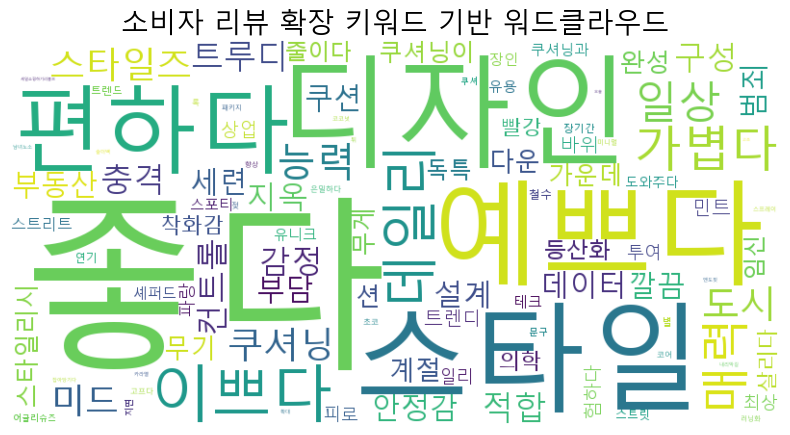

In [16]:
font_path = "C:/Windows/Fonts/malgun.ttf"
font_name = fm.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 브랜드가 강조하는 키워드 리스트
attribute_keywords = [
    "디자인", "스타일", "트렌드", "세련", "감각적", "예쁘다", 
    "깔끔함", "미니멀", "데일리", "유니크", "클래식한", '아웃도어 감성+도심에서도 어울림',
    "블랙 팬텀", "깔끔", "도시","고성능",
    "편하다", "가볍다", "푹신하다", "쿠션감", "착화감", "좋다", "안정감",
    "오래", "맞음", "EndoFit", "엔도핏", "장시간",
    "기능성", "러닝화", "지지력", "접지력", "통기성", "내구성", "튼튼", "통풍", "시원",
    "쿠셔닝", "부드러운", "충격", "튼튼함",
    "내리막길", "러그 구조", "컨트롤"
]

def load_tokenized_reviews(csv_path):
    df = pd.read_csv(csv_path)
    df['tokens'] = df['0'].apply(eval) 
    return df

def train_word2vec_model(reviews_tokens):
    model = Word2Vec(sentences=reviews_tokens, vector_size=100, window=5, min_count=2, workers=4, epochs=20)
    return model

def expand_keywords_with_word2vec(model, keywords, topn=5, similarity_threshold=0.6):
    expanded_keywords = set(keywords) 
    
    for kw in keywords:
        if kw in model.wv: 
            similar_words = model.wv.most_similar(kw, topn=topn)
            for word, score in similar_words:
                if score >= similarity_threshold: 
                    expanded_keywords.add(word) 
    
    return expanded_keywords

def count_keywords_in_reviews(df, keywords):
    keyword_count = defaultdict(int)
    keyword_matching_reviews = defaultdict(int)  # 키워드가 등장한 리뷰 수

    for i, tokens in enumerate(df['tokens']):
        matched_keywords_in_review = set()
        for word in tokens:
            if word in keywords:
                keyword_count[word] += 1
                matched_keywords_in_review.add(word)
        
        if matched_keywords_in_review:
            for matched_word in matched_keywords_in_review:
                keyword_matching_reviews[matched_word] += 1
                
    return keyword_count, keyword_matching_reviews

# 일치율 계산
def calculate_matching_rate(keyword_matching_reviews, total_reviews):
    matching_rate = {k: round(v / total_reviews * 100, 2) for k, v in keyword_matching_reviews.items()}
    return matching_rate

def generate_wordcloud(freq_dict, title):
    wc = WordCloud(
        font_path=font_path,
        background_color="white",
        width=800,
        height=400,
        max_words=100
    )
    wc.generate_from_frequencies(freq_dict)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=20)
    plt.show()

# 파이프라인
def main(csv_file):
    # 리뷰 불러오기
    df = load_tokenized_reviews(csv_file)
    reviews_tokens = df['tokens'].tolist()

    # Word2Vec 모델 학습
    model = train_word2vec_model(reviews_tokens)

    # 키워드 확장
    expanded_keywords = expand_keywords_with_word2vec(model, attribute_keywords)

    # 리뷰에서 속성별 키워드 등장 횟수 세기
    keyword_count, keyword_matching_reviews = count_keywords_in_reviews(df, expanded_keywords)

    # 총 리뷰 수
    total_reviews = len(df)
    
    # 일치율 계산
    matching_rate = calculate_matching_rate(keyword_matching_reviews, total_reviews)

    # 결과 출력
    print("속성별 키워드 등장 횟수:", dict(keyword_count))
    print("각 키워드의 일치율 (%):", matching_rate)

    # 워드클라우드 생성: 브랜드 강조 키워드 빈도 (소비자 리뷰 기준)
    generate_wordcloud(keyword_count, "소비자 리뷰 확장 키워드 기반 워드클라우드")

if __name__ == "__main__":
    csv_file = "processed_reviews.csv"
    main(csv_file)


# **감성분석**

확장된 긍정 단어 수: 8
확장된 부정 단어 수: 21
=== 브랜드 리뷰 총 감성 요약 ===
긍정 단어가 포함된 리뷰 수: 1366 (74.08%)
부정 단어가 포함된 리뷰 수: 777 (42.14%)
리뷰 평균 감성 점수 (긍정 단어 수 - 부정 단어 수): 1.975


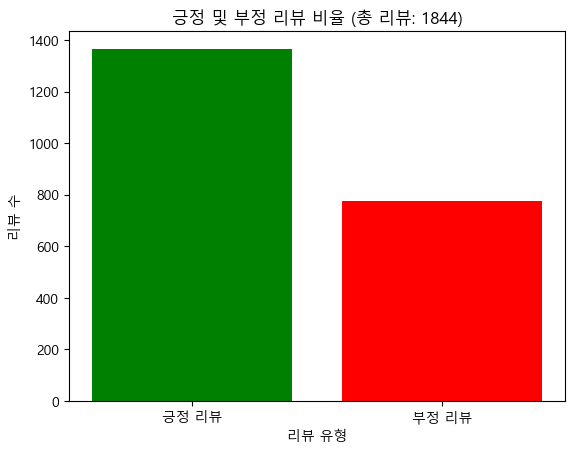

In [17]:
# 감성 어휘 사전 
positive_words = ["좋다", "좋아요", "편하다", "예쁘다", "이쁘다", "만족", "푹신", "가볍다"]
negative_words = ["불편", "불만", "무겁다", "아프다", "불편하다", "불만족", "작다", "크다"]


def expand_sentiment_words(base_words, model, threshold=0.75, topn=10):
    expanded_set = set(base_words)
    for word in base_words:
        try:
            similars = model.wv.most_similar(word, topn=topn)
            for sim_word, score in similars:
                if score >= threshold:
                    expanded_set.add(sim_word)
        except KeyError:
            continue
    return expanded_set

def match_sentiment(tokens, pos_set, neg_set):
    pos_matches = [token for token in tokens if token in pos_set]
    neg_matches = [token for token in tokens if token in neg_set]
    return pos_matches, neg_matches

def apply_sentiment_analysis(df, expanded_positive, expanded_negative):
    df['pos_matches'], df['neg_matches'] = zip(*df['tokens'].apply(lambda x: match_sentiment(x, expanded_positive, expanded_negative)))
    df['pos_count'] = df['pos_matches'].apply(len)
    df['neg_count'] = df['neg_matches'].apply(len)
    df['sentiment_score'] = df['pos_count'] - df['neg_count']

def sentiment_summary(df):
    total_reviews = len(df)
    num_pos_reviews = (df['pos_count'] > 0).sum()
    num_neg_reviews = (df['neg_count'] > 0).sum()
    avg_sentiment_score = df['sentiment_score'].mean()

    print("=== 브랜드 리뷰 총 감성 요약 ===")
    print(f"긍정 단어가 포함된 리뷰 수: {num_pos_reviews} ({num_pos_reviews/total_reviews*100:.2f}%)")
    print(f"부정 단어가 포함된 리뷰 수: {num_neg_reviews} ({num_neg_reviews/total_reviews*100:.2f}%)")
    print(f"리뷰 평균 감성 점수 (긍정 단어 수 - 부정 단어 수): {avg_sentiment_score:.3f}")

    return num_pos_reviews, num_neg_reviews, total_reviews

def plot_sentiment_ratio(num_pos_reviews, num_neg_reviews, total_reviews):
    labels = ['긍정 리뷰', '부정 리뷰']
    values = [num_pos_reviews, num_neg_reviews]

    plt.bar(labels, values, color=['green', 'red'])
    plt.xlabel('리뷰 유형')
    plt.ylabel('리뷰 수')
    plt.title(f'긍정 및 부정 리뷰 비율 (총 리뷰: {total_reviews})')
    plt.show()

def print_expanded_sentiment_word_count(expanded_positive, expanded_negative):
    print(f"확장된 긍정 단어 수: {len(expanded_positive)}")
    print(f"확장된 부정 단어 수: {len(expanded_negative)}")

# 파이프라인
def main(csv_file):
    # 리뷰 불러오기
    df = load_tokenized_reviews(csv_file)
    reviews_tokens = df['tokens'].tolist()

    # Word2Vec 모델 학습
    model = train_word2vec_model(reviews_tokens)

    # 감성 단어 확장
    expanded_positive = expand_sentiment_words(positive_words, model)
    expanded_negative = expand_sentiment_words(negative_words, model)

    # 확장된 감성 단어 수 출력
    print_expanded_sentiment_word_count(expanded_positive, expanded_negative)

    # 감성 분석 적용
    apply_sentiment_analysis(df, expanded_positive, expanded_negative)

    # 감성 요약 출력
    num_pos_reviews, num_neg_reviews, total_reviews = sentiment_summary(df)

    # 긍부정 비율 시각화
    plot_sentiment_ratio(num_pos_reviews, num_neg_reviews, total_reviews)

if __name__ == "__main__":
    csv_file = "processed_reviews.csv" 
    main(csv_file)


# **분류**

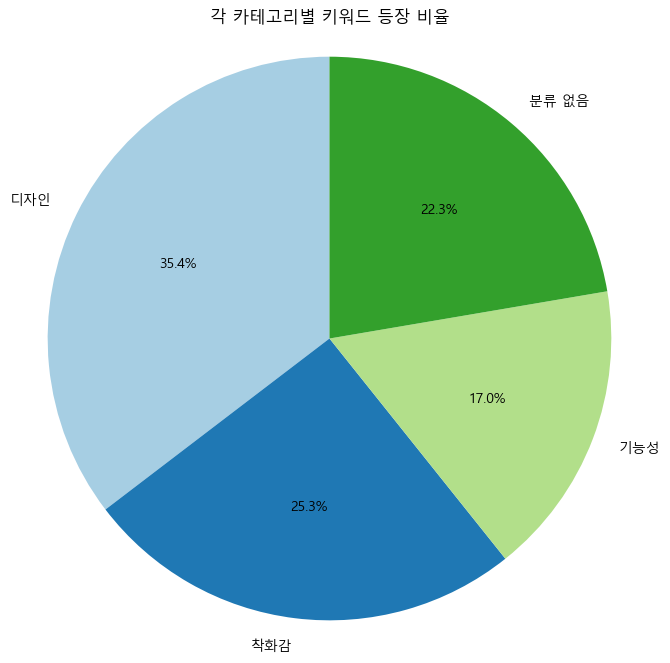

In [18]:
category_keywords = {
    '디자인': ['디자인', '패션', '핏', '스타일', '실루엣', '모델', '트렌드', '레이어드', '유행', '예쁘다', '이쁘다'],
    '기능성': ['기술', '고성능', '지지력', '충격 흡수', '향상', '러닝화', '구조', '튼튼', '단단', '충격', '흡수', '시원', '러닝'],
    '착화감': ['볼륨감', '갑피', '소재', '탁월', '착화감', '착용감', '편하다']
}

def expand_keywords_with_word2vec(model, category_keywords, topn=5, similarity_threshold=0.6):
    expanded_keywords = {}

    for category, keywords in category_keywords.items():
        expanded_category_keywords = set(keywords)
        for kw in keywords:
            if kw in model.wv:
                similar_words = model.wv.most_similar(kw, topn=topn)
                for word, score in similar_words:
                    if score >= similarity_threshold:
                        expanded_category_keywords.add(word)
        expanded_keywords[category] = expanded_category_keywords

    return expanded_keywords

def classify_keywords_in_reviews(df, expanded_keywords):
    category_counts = defaultdict(int)

    for tokens in df['tokens']:
        matched_categories = set()
        for word in tokens:
            for category, keywords in expanded_keywords.items():
                if word in keywords:
                    matched_categories.add(category)

        if matched_categories:
            for category in matched_categories:
                category_counts[category] += 1
        else:
            category_counts["분류 없음"] += 1 

    return category_counts

def plot_pie_chart(category_counts):
    labels = list(category_counts.keys())
    sizes = list(category_counts.values())

    plt.figure(figsize=(8, 8))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
    plt.title("각 카테고리별 키워드 등장 비율")
    plt.axis('equal')
    plt.show()

# 파이프라인
def main(csv_file):
    # 리뷰 불러오기
    df = load_tokenized_reviews(csv_file)
    reviews_tokens = df['tokens'].tolist()

    # Word2Vec 모델 학습
    model = train_word2vec_model(reviews_tokens)

    # 키워드 확장
    expanded_keywords = expand_keywords_with_word2vec(model, category_keywords)

    # 키워드 분류
    category_counts = classify_keywords_in_reviews(df, expanded_keywords)

    # 파이차트 그리기
    plot_pie_chart(category_counts)

if __name__ == "__main__":
    csv_file = "processed_reviews.csv" 
    main(csv_file)
